# Atmospheric Retrievals with POSEIDON

In [1]:
import numpy as np
from POSEIDON.core import create_star, create_planet, load_data, wl_grid_constant_R, define_model, set_priors, read_opacities
from POSEIDON.constants import R_Sun, R_J
from POSEIDON.visuals import plot_data, plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot, generate_overplot
from POSEIDON.retrieval import run_retrieval, Bayesian_model_comparison
from POSEIDON.utility import read_retrieved_spectrum, plot_collection

# Define stellar properties - WASP-999
R_s = 1.155 * R_Sun   # Stellar radius [m]
T_s = 6071.0          # Effective temp. [K]
Met_s = 0.0           # Metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.38        # Log surface gravity [log10(cm/s^2)], by convention

star = create_star(R_s, T_s, Met_s, log_g_s)

# Define planetary properties - WASP-999b
planet_name = 'WASP-999b'
R_p = 1.359 * R_J     # White-light planetary radius [m]
g_p = 9.186           # Gravitational field of planet [m/s^2]
T_eq = 1400.0         # Equilibrium temp [K]

planet = create_planet(planet_name, R_p, gravity = g_p, T_eq = T_eq)

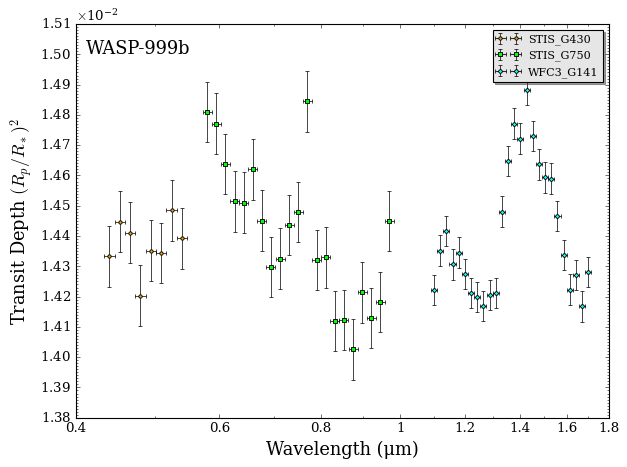

In [2]:
# Plot observed transmission spectrum
wl_min = 0.40    # Min and max wavelengths [$\mu$m]
wl_max = 3.0
res = 4000       # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, res)

# Get datasets 
# POSEIDON wants .dat files with the following format: wavelength [$\mu$m] | bin half width [$\mu$m] | transit depth [(Rp/R*)*2] | transit depth error
data_dir = '/home/peng/POSEIDON/POSEIDON/reference_data/observations/WASP-999b'
datasets = ['WASP-999b_STIS_G430.dat',
            'WASP-999b_STIS_G750.dat',
            'WASP-999b_WFC3_G141.dat']
instruments = ['STIS_G430', 'STIS_G750', 'WFC3_G141']

# Load and plot data
data = load_data(data_dir, datasets, instruments, wl)
fig_data = plot_data(data, planet_name)

# First retrieval model

In [3]:
# Create retrieval model - guess what's in the planet
model_name = 'test_retrieval'
bulk_species = ['H2', 'He']   # What makes up most of the atm?
param_species = ['H2O']       # What do you want to test for? 

model = define_model(model_name, bulk_species, param_species, PT_profile = 'isotherm', cloud_model = 'cloud-free')

# Check free parameters that define the model
# For this model, they are the radius at the fixed reference pressure, isothermal atmospheric temp and log-mixing ratio of H2O
print('Free parameters: '+ str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O']


In [4]:
# Set priors for retrieval
# Most priors with POSEIDON are uniform (min, max) or gaussian (mean, stdev)
# Prior types
prior_types = {}
prior_types['T'] = 'uniform'
prior_types['R_p_ref'] = 'uniform'
prior_types['log_H2O'] = 'uniform'

# Prior ranges
prior_ranges = {}
prior_ranges['T'] = [400, 1600]
prior_ranges['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges['log_H2O'] = [-12, -1]

priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

In [5]:
# Pre-load opacities - pre-interpolate cross-section and opacity data required by model
opacity_treatment = 'opacity_sampling'

# Define fine temp. and pressure grids, these should cover a wide range 
# Ranges of Tfine, [K], must be at least as large as the prior ranges
Tf_min = 400
Tf_max = 1600
Tf_step = 10     # Increase/decrease step size to compensate for accuracy vs RAM usage

T_fine = np.arange(Tf_min, Tf_max + Tf_step, Tf_step)

# Define fine pressure grid, [log10(P/bar)]
log_Pf_min = -6.0     # 1 $\mu$bar is lowest pressure in database
log_Pf_max = 2.0      # 100 bar is the highest
log_Pf_step = 0.2     # Increase/decrease step size to compensate for accuracy vs RAM usage

log_Pfine = np.arange(log_Pf_min, log_Pf_max + log_Pf_step, log_Pf_step)

# Pre-interpolate opacities
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_Pfine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Opacity pre-interpolation complete.


In [6]:
# Run retrieval
# If you just do it on here, it only uses 1 core (~10 minutes for 3 param fit)
# Can convert this into .py file and call mpirun on it: mpirun -n 4 python -u (retrievalscript).py

# Specify fixed atmospheric settings for retrieval and space layers of atmosphere evenly in log-pressure
Pmin = 1.0e-7   # 0.1 $\mu$bar
Pmax = 100      # 100 bar
N_layers = 100 

P = np.logspace(np.log10(Pmax), np.log10(Pmin), N_layers)

# Specify reference pressure, R_p_ref will be radius at this pressure
P_ref = 10.0

# Run retrieval, increase N_live up to 2000 to sample parameter space more finely --> publication-quality results
run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = True) 

POSEIDON now running 'test_retrieval'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.995575
Replacements:                                450
Total Samples:                               452
Nested Sampling ln(Z):            -123582.376204
Acceptance Rate:                        0.988142
Replacements:                                500
Total Samples:                               506
Nested Sampling ln(Z):             -83261.899536
Acceptance Rate:                        0.951557
Replacements:                                550
Total Samples:                               578
Nested Sampling ln(Z):             -62587.752920
Acceptance Rate:                        0.910470
Repla

Generating corner plot ...


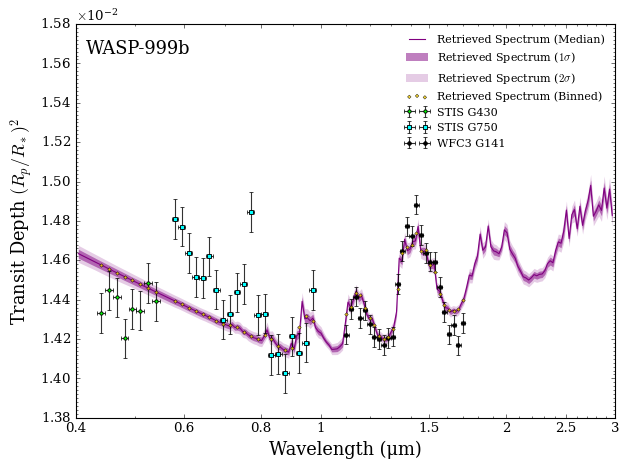

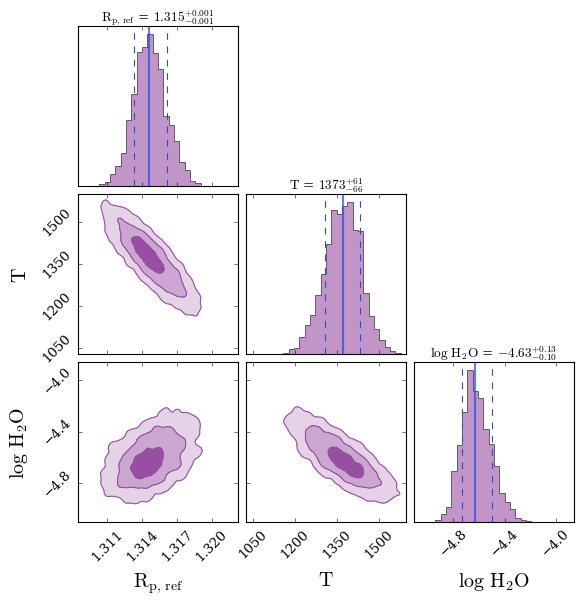

In [26]:
# Plot retrieval results
# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Create objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce spectrum and corner plots
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100, 
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'], data_colour_list = ['lime', 'cyan', 'black']) 

fig_corner = generate_cornerplot(planet, model)

# These two plots can be found in /POSEIDON_output/planet/plots and /POSEIDON_output/planet/retrievals/results - folder with corner plot also has a results file

From this fit, reduced chi^2 is >3 which is much larger than 1, so let's try:
# Second retrieval model

In [8]:
# Define new model and more species
model_name2 = 'Improved_retrieval'

bulk_species = ['H2', 'He']
param_species2 = ['Na', 'K', 'TiO', 'H2O']   # Add Na, K and TiO to first model

# Create new model object
model2 = define_model(model_name2, bulk_species, param_species2, PT_profile = 'isotherm', cloud_model = 'cloud-free')

# Now printing param_names will give log mixing ratios of Na, K and TiO as well as H2O - 6-param fit will take about 20 minutes on 1 core
print("Free parameters: " + str(model2['param_names']))

# Set priors for new retrieval
prior_types2, prior_ranges2 = {}, {}
prior_types2['T'], prior_ranges2['T'] = 'uniform', [400, 1600]
prior_types2['R_p_ref'], prior_ranges2['R_p_ref'] = 'uniform', [0.85*R_p, 1.15*R_p]
prior_types2['log_X'], prior_ranges2['log_X'] = 'uniform', [-12, -1]     # log_X sets priors for all mixing ratios

priors2 = set_priors(planet, star, model2, data, prior_types2, prior_ranges2)

# Pre-interpolate opacities
opac2 = read_opacities(model2, wl, opacity_treatment, T_fine, log_Pfine)

Free parameters: ['R_p_ref' 'T' 'log_Na' 'log_K' 'log_TiO' 'log_H2O']
Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
TiO done
H2O done
Opacity pre-interpolation complete.
POSEIDON now running 'Improved_retrieval'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    6
 *****************************************************
POSEIDON retrieval finished in 0.35 hours ln(ev)=   430.10982255478928      +/-  0.19554238157968964     
 Total Likelihood Evaluations:        26469
 Sampling finished. Exiting MultiNest

Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.83 minutes
All done! Output files can be found in ./POSEIDON_output/WASP-999b/retrievals/results/


In [ ]:
# Run retrieval
run_retrieval(planet, star, model2, opac2, data, priors2, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

Generating corner plot ...


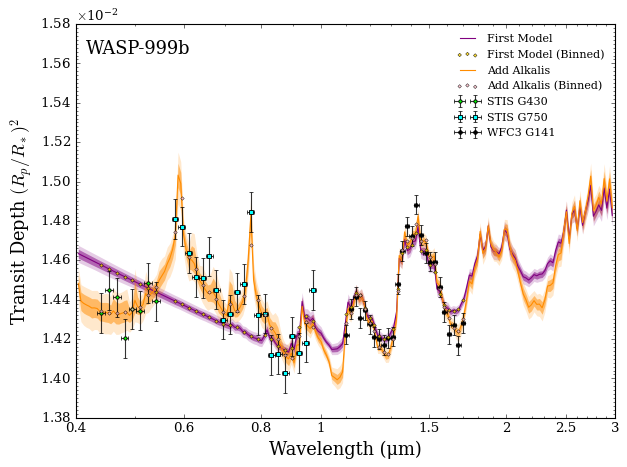

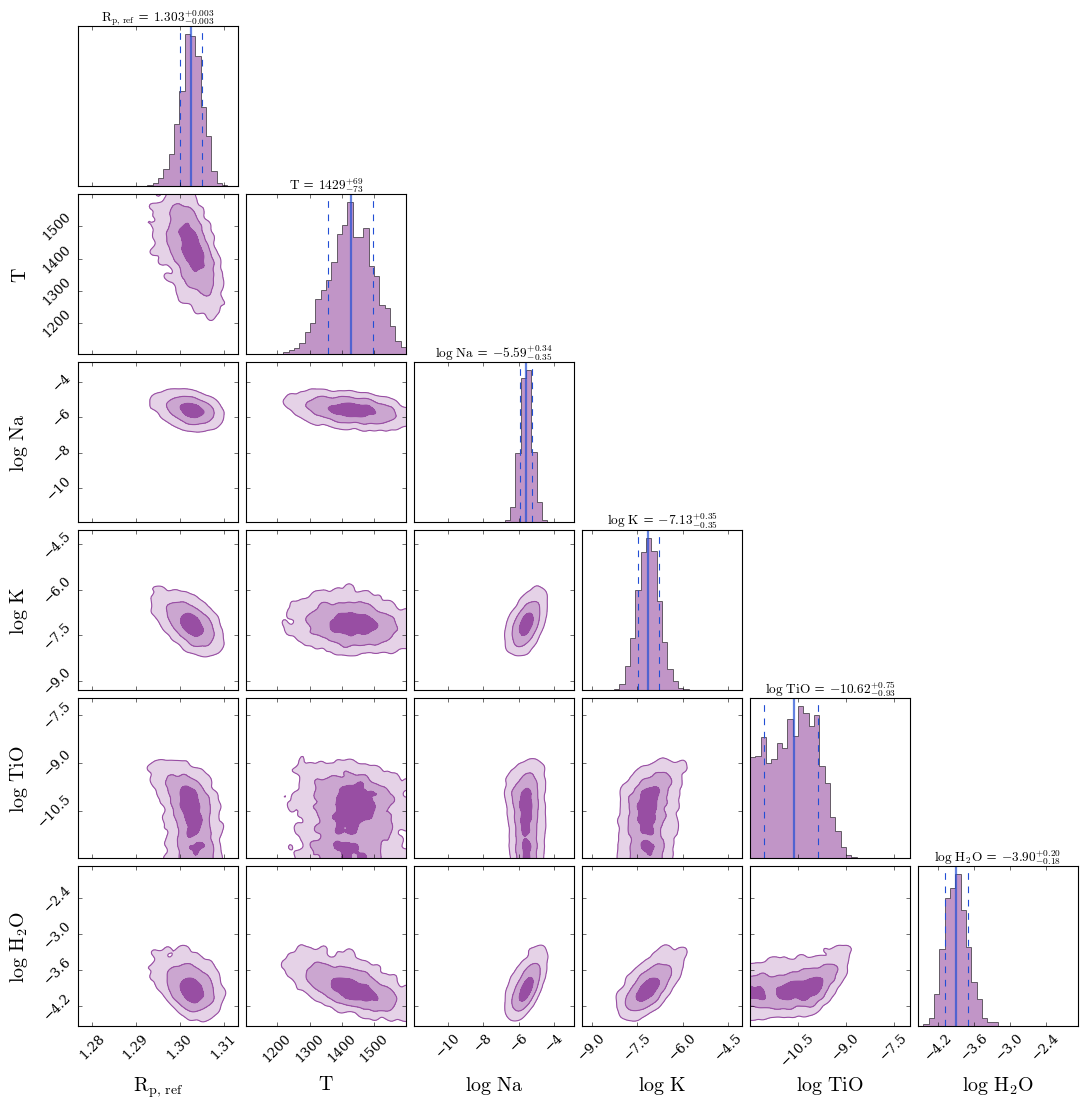

In [27]:
# Plot retrieval results
wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name2)

spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, planet_name, data, R_to_bin = 100, 
                                  spectra_labels = ['First Model', 'Add Alkalis'], data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'])

fig_corner = generate_cornerplot(planet, model2)

The reduced chi^2 is now less than 1, which suggests over-fitting. We can try two more models which take out water and titanium oxide, then use
# Bayesian Model Comparisons
to compare them

They yap for a little bit so I'll just summarize the yap here:

The reduced $\chi ^2$ value is a good way to see (roughly) if you have a good fit (close to 1 is good, less than 1 is overfit), but we can be more detailed. 

So far what we did with the first two models is Bayesian **parameter estimation**: given a model, what ranges of the model params give a good fit?

Bayesian **model comparison** is more like: given *many* models, which is better at explaining the data?

We can use the Bayes factor, *$B_{12}$*, to tell us the ratio between the Bayesian evidences, $Z$, of one model and another. This is usually represented as some detection significance, or some number of $\sigma$. We can use model2 as the reference model, then make two new ones each removing something and comparing them to the reference. This will tell us how significant the detections of the removed species are. 

In [40]:
# Make new models
model_name3 = 'No_H2O'
model_name4 = 'No_TiO'

param_species3 = ['Na', 'K', 'TiO']   # No water
param_species4 = ['Na', 'K', 'H2O']   # No titanium oxide

# Create model objects
model3 = define_model(model_name3, bulk_species, param_species3, PT_profile = 'isotherm', cloud_model = 'cloud-free')
model4 = define_model(model_name4, bulk_species, param_species4, PT_profile = 'isotherm', cloud_model = 'cloud-free')

# Use the same priors as model2, since we defined log_X

# Opacity
opac3 = read_opacities(model3, wl, opacity_treatment, T_fine, log_Pfine)
opac4 = read_opacities(model4, wl, opacity_treatment, T_fine, log_Pfine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
TiO done
Opacity pre-interpolation complete.
Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
H2O done
Opacity pre-interpolation complete.


In [41]:
# Run retrievals
run_retrieval(planet, star, model3, opac3, data, priors2, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

run_retrieval(planet, star, model4, opac4, data, priors2, wl, P, P_ref, spectrum_type = 'transmission', 
              sampling_algorithm = 'MultiNest', N_live = 400, verbose = False)

# MultiNest will print out convergence warnings if something unusual happens, for example, a fit is converging to the edge of a prior

POSEIDON now running 'No_H2O'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode     

In [42]:
# POSEIDON can automatically carry out bayesian model comparison
model_ref = model2
model_no_h2o = model3
model_no_tio = model4

# H2O model comparison
Bayesian_model_comparison(planet_name, model_ref, model_no_h2o)

Bayesian evidences:

Model Improved_retrieval: ln Z = 430.11 +/- 0.20
Model No_H2O: ln Z = 163.08 +/- 0.19

Bayes factor:

B = 9.29e+115
ln B = 267.03

'Equivalent' detection significance:

23.2 σ



Generating corner plot ...


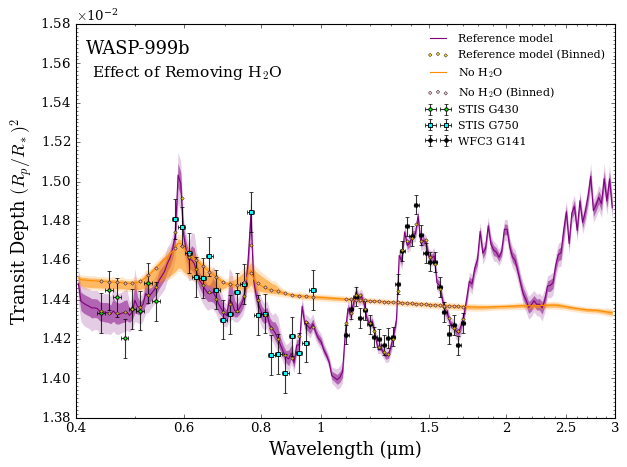

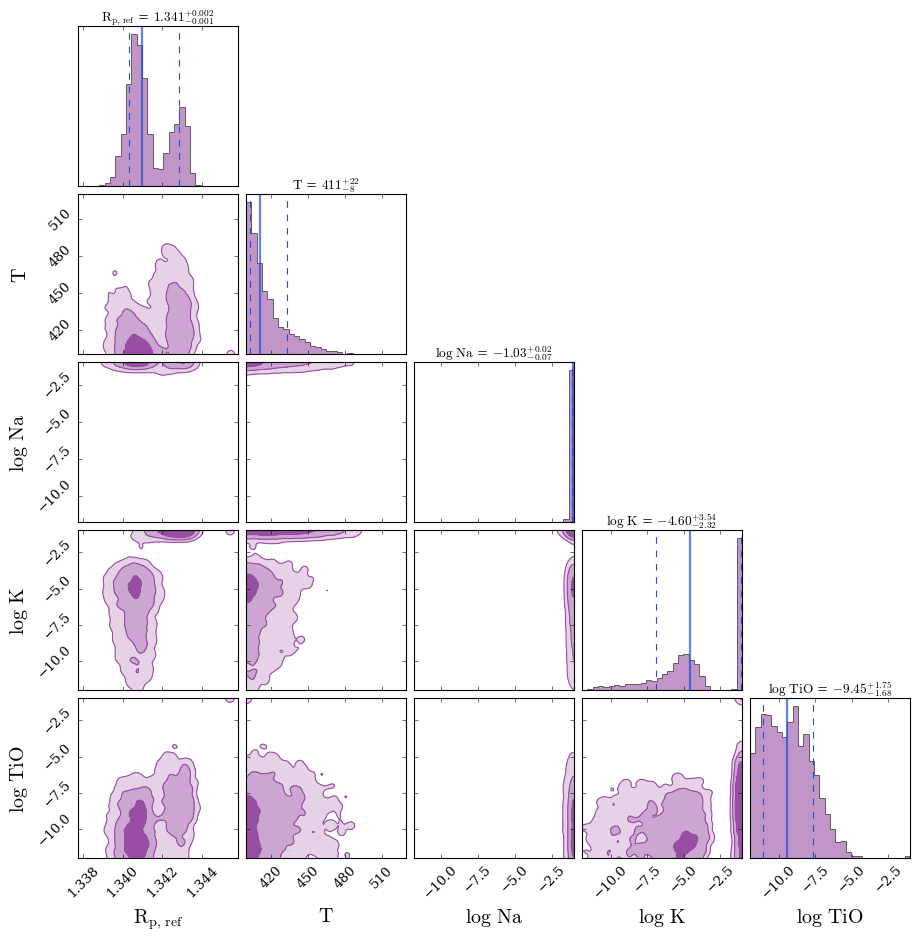

In [43]:
# Plot retrieved spectrum for model without water
# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_ref['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_no_h2o['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  spectra_labels = ['Reference model', 'No H$_2$O'],
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'],
                                  plt_label = 'Effect of Removing H$_2$O')

fig_corner = generate_cornerplot(planet, model_no_h2o)

In [44]:
# TiO model comparison
Bayesian_model_comparison(planet_name, model_ref, model_no_tio)

Bayesian evidences:

Model Improved_retrieval: ln Z = 430.11 +/- 0.20
Model No_TiO: ln Z = 430.99 +/- 0.19

Bayes factor:

B = 4.16e-01
ln B = -0.88

No detection of the reference model, model No_TiO is preferred.



Generating corner plot ...


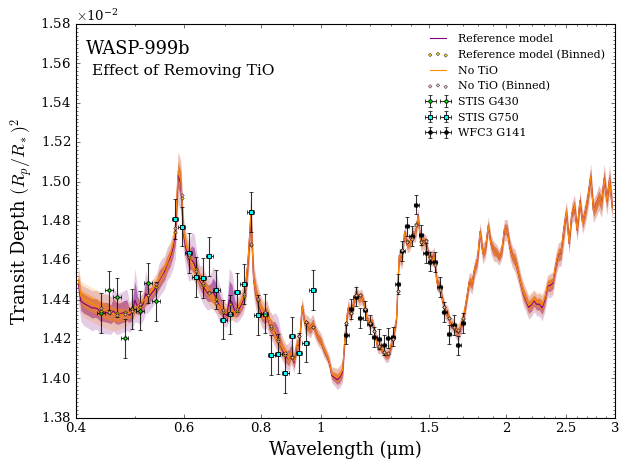

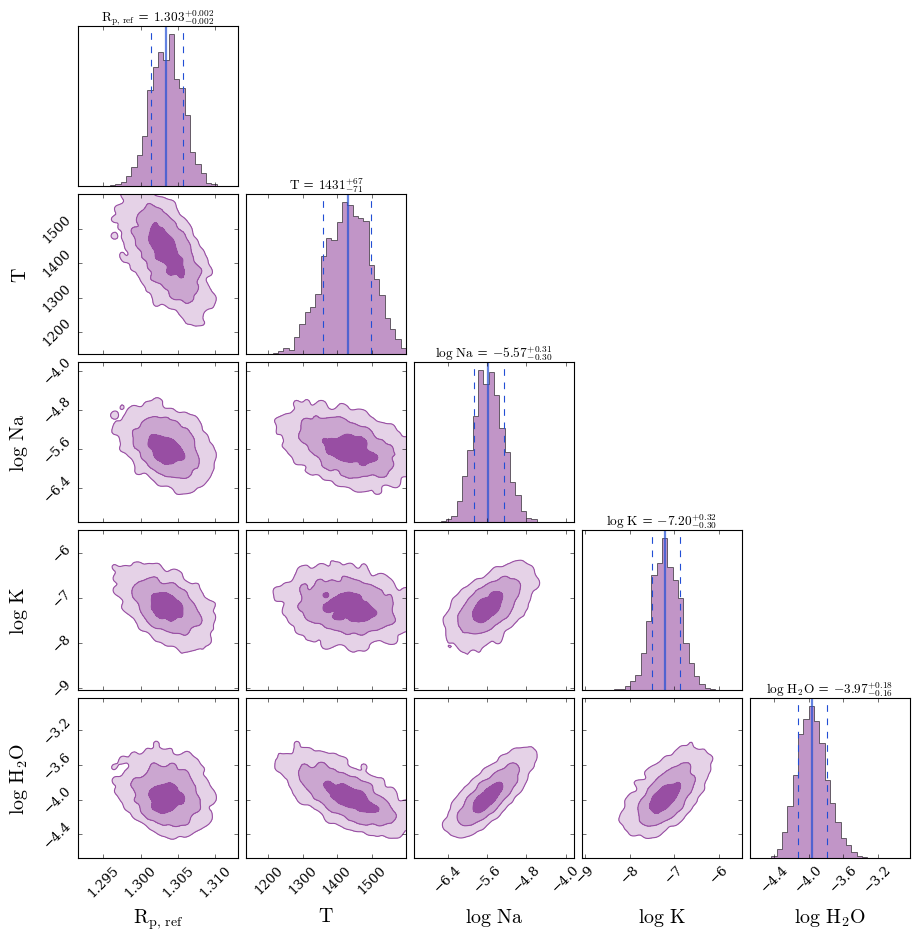

In [45]:
#  Plot retrieved spectrum for model without titanium oxide
# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_ref['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_no_tio['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  spectra_labels = ['Reference model', 'No TiO'],
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'],
                                  plt_label = 'Effect of Removing TiO')

fig_corner = generate_cornerplot(planet, model_no_tio)